In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/motion_CNN
    filepath = "/content/drive/MyDrive/NUIN/mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat" 
    !git pull
else: 
  filepath =  "mouse_scenes/20210916_252MEA_mouse_right_half_ventral/fixationmovie_data.mat"
    

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NUIN/motion_CNN
Already up to date.


In [2]:
from utilities import CorrelationVelDataset, show_batch_frames, show_one_sample_summary, sample_animation, split_by_source_image, prerender_dataset_to_single_pt, TensorMovieDataset
from IPython.display import HTML, display
import torch.nn as nn
import torch.nn.functional as F
import torch
from torch.utils.data import Subset, DataLoader
import os 
import numpy as np
import matplotlib.pyplot as plt

# Set the resolution for figures displayed in the notebook
plt.rcParams['figure.dpi'] = 100


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   
print(f"Using device: {device}")
print(os.getcwd())

Using device: cuda
/content/drive/MyDrive/NUIN/motion_CNN


In [4]:
dataset = CorrelationVelDataset(
    file = filepath,
    crop_hw=(400,400),
    downsample_hw=(50,50),
    frames_per_segment=75,
    fps = 75,
    samples_per_image= 6, 
    vel_std = (350,350),
    vel_corr=-0.0
    )

print("dataset length:", len(dataset))

dataset length: 1950


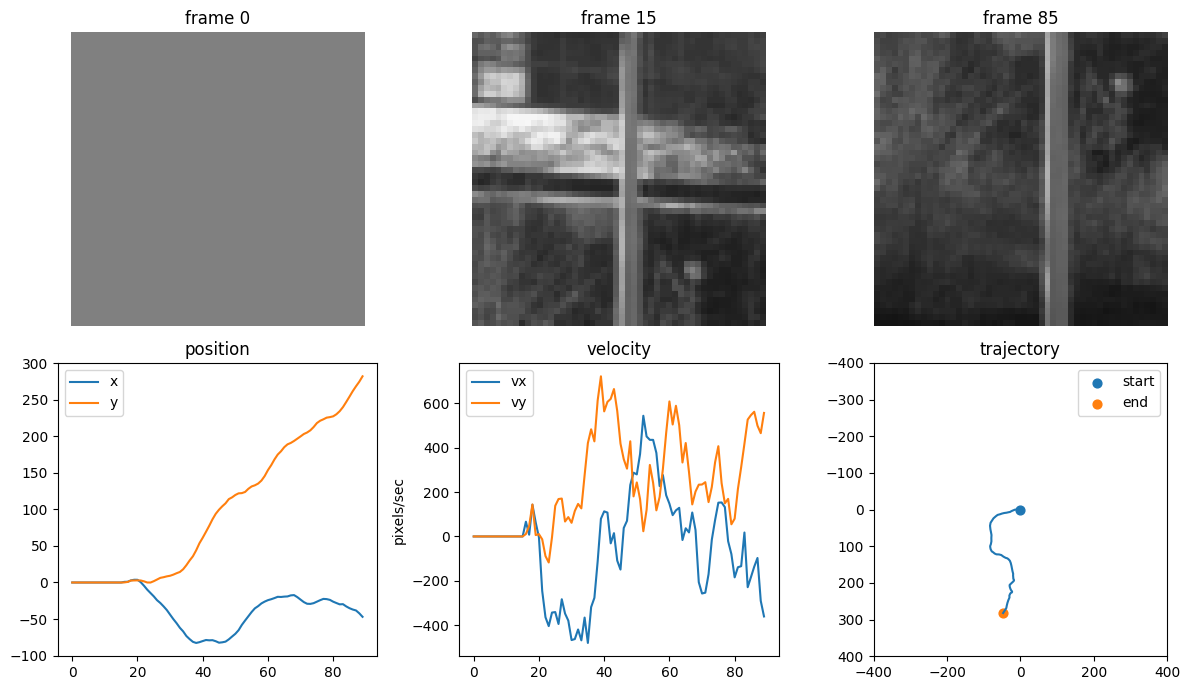

In [5]:
show_one_sample_summary(dataset, 0, frame_indices=[0,15,85])

In [6]:

# anim = sample_animation(dataset, 0, viz_fps=20, save_path=None)
# display(HTML(anim.to_jshtml()))

# Split/Val sets

In [7]:

train_dataset, val_dataset, train_keys, val_keys = split_by_source_image(
    dataset,
    train_frac=0.8,
    val_frac=0.2,
    seed=0,
)
print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

print("Train images:", len(train_keys))
print("Val images:", len(val_keys))

print("Overlap:", len(train_keys & val_keys))

Total samples: 1950
Train samples: 1560
Val samples: 390
Train images: 260
Val images: 65
Overlap: 0


In [8]:
cache_name_train = (
    f"corrvel_train_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

cache_name_val = (
    f"corrvel_val_"
    f"hw{dataset.downsample_hw[0]}x{dataset.downsample_hw[1]}_"
    f"T{dataset.frames_per_segment}_"
    f"gray{dataset.gray_frames}_"
    f"std{dataset.vel_std}_"
    f"corr{dataset.vel_corr}_"
    f"seed{dataset.random_seed}.pt"
)

train_cache = prerender_dataset_to_single_pt(
    dataset,
    train_dataset.indices,
    f"cache/{cache_name_train}",
    movie_dtype=torch.float16,
    overwrite=False,
)

val_cache = prerender_dataset_to_single_pt(
    dataset,
    val_dataset.indices,
    f"cache/{cache_name_val}",
    movie_dtype=torch.float16,
    overwrite=False,
)

Cache already exists, skipping render: cache/corrvel_train_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt
Cache already exists, skipping render: cache/corrvel_val_hw50x50_T75_gray15_std(350, 350)_corr-0.0_seed0.pt


In [9]:
cached_train = TensorMovieDataset(f"cache/{cache_name_train}", movie_dtype=torch.float32)
cached_val = TensorMovieDataset(f"cache/{cache_name_val}", movie_dtype=torch.float32)

train_loader = DataLoader(
    cached_train,
    batch_size=16,
    shuffle=True,
    num_workers=0,   # try 0 first; increase later
    pin_memory=True,
)

val_loader = DataLoader(
    cached_val,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

## Tiny CNN

In [10]:
class CNN(nn.Module):
    """
    A convolutional neural network (CNN) model for RGC. The model consists 
    of a series of convolutional layers followed by a fully connected layer 
    to produce the mean of a Poisson spike count distribution. The model also 
    includes a nonlinear activation function between layers to capture nonlinear 
    features of the stimulus.

    Parameters
    ----------
    num_neurons : int
        The number of OUTPUT neurons in the model.
    height : int
        The height of the stimulus in pixels.
    width : int
        The width of the stimulus in pixels.
    max_delay : int
        The maximum delay in frames for the temporal convolution.
    rf_size_1 : int
        The size of the receptive field for the first layer.
    rf_size_2 : int
        The size of the receptive field for the second layer.
    num_subunits_1 : int
        The number of subunits in the first layer.
    num_subunits_2 : int
        The number of subunits in the second layer.
    mean_function : callable
        The function to compute the mean of the Poisson distribution.
    initial_bias : float
        The initial bias for the temporal convolution.
    spatial_conv : nn.Conv2d
        The convolutional layer for the spatial convolution.
    temporal_conv : nn.Conv1d
        The convolutional layer for the temporal convolution.
    layer2 : nn.Conv2d
        The convolutional layer for the second layer.
    layer3 : nn.Linear
        The fully connected layer for the output.
    """
    num_neurons: int
    height: int
    width: int
    max_delay: int
    rf_size_1: int
    rf_size_2: int
    num_subunits_1: int
    num_subunits_2: int
    mean_function: callable
    spatial_conv: nn.Conv2d
    temporal_conv: nn.Conv1d
    layer2: nn.Conv2d
    layer3: nn.Linear

    def __init__(self,
                 num_neurons: int = 8,
                 height: int = 50,
                 width: int = 50,
                 rf_size_1: int = 15,
                 rf_size_2: int = 11,
                 max_delay: int = 70,
                 num_subunits_1: int = 8,
                 num_subunits_2: int = 8,
                 initial_bias: float = 1.0,
                 mean_function: callable = F.softplus):

        super().__init__()
        self.num_neurons = num_neurons
        self.height = height
        self.width = width
        self.max_delay = max_delay
        self.rf_size_1 = rf_size_1
        self.rf_size_2 = rf_size_2
        self.num_subunits_1 = num_subunits_1
        self.num_subunits_2 = num_subunits_2
        self.mean_function = mean_function

        # ---- 1a. First spatial conv (rank-1 spatial part) ----
        # [T, 1, H, W] -> [T, N1, H1, W1]
        self.spatial_conv = nn.Conv2d(
            in_channels=1,
            out_channels=num_subunits_1,
            kernel_size=rf_size_1,
            padding=0,           # valid conv
            bias=True,
        )

        # Compute spatial sizes after conv1 (valid padding)
        H1 = height - rf_size_1 + 1
        W1 = width - rf_size_1 + 1
        self.H1 = H1
        self.W1 = W1

        # ---- 1b. Temporal conv (rank-1 temporal part) ----
        # We want a per-subunit temporal filter, shared across space:
        # input to Conv1d: [batch=H1*W1, C=N1, T]
        # groups=N1 => one temporal filter per subunit
        self.temporal_conv = nn.Conv1d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_1,
            kernel_size=max_delay,
            groups=num_subunits_1,
            bias=True,
        )

        # ---- 2a. Second spatial conv + mixing ----
        # [T, N1, H1, W1] -> [T, N2, H2, W2]
        self.layer2 = nn.Conv2d(
            in_channels=num_subunits_1,
            out_channels=num_subunits_2,
            kernel_size=rf_size_2,
            padding=0,
            bias=True,
        )

        # Spatial sizes after second conv
        H2 = H1 - rf_size_2 + 1
        W2 = W1 - rf_size_2 + 1
        self.H2 = H2
        self.W2 = W2

        # ---- 3a. Linear readout from N2 × H2 × W2 to N neurons ----
        self.layer3 = nn.Linear(num_subunits_2 * H2 * W2, num_neurons)

        # inverse softplus of initial_rate
        bias = torch.log(torch.exp(torch.tensor(float(initial_bias))) - 1.0)
        nn.init.constant_(self.layer3.bias, bias)

    def forward(
        self,
        movie):
        """
        movie: (B, T, 1, H, W)
        returns: rates, shape (B, T, num_neurons)
        """
        B, T, C, H, W = movie.shape

        # -------------------------------------------------------
        # 1. Spatial conv per frame
        # -------------------------------------------------------
        x = movie.reshape(B * T, C, H, W)          # (B*T, 1, H, W)
        x = self.spatial_conv(x)                  # (B*T, N1, H1, W1)

        _, N1, H1, W1 = x.shape
        
        #restore Batch over time 
        x = x.reshape(B, T, N1, H1, W1)           # (B, T, N1, H1, W1)
        
        # -------------------------------------------------------
        # 2. Tempo conv at each spatial location
        # -------------------------------------------------------
        #NOTE: tempconv expects (B, C, T)
        x = x.permute(0, 3, 4, 2, 1)              # (B, H1, W1, N1, T)
        x = x.reshape(B * H1 * W1, N1, T)         # (B*H1*W1, N1, T)

        # Causal padding: prediction at time t only sees current/past frames
        x = F.pad(x, (self.max_delay - 1, 0))     # (B*H1*W1, N1, T+delay-1)
        x = self.temporal_conv(x)                 # (B*H1*W1, N1, T)

        # Back to movie-like tensor
        x = x.reshape(B, H1, W1, N1, T)
        x = x.permute(0, 4, 3, 1, 2)              # (B, T, N1, H1, W1)

        x = F.relu(x)
        
        # -------------------------------------------------------
        # 3. 2nd spatial conv 
        # -------------------------------------------------------
        
        x = x.reshape(B * T, N1, H1, W1)          # (B*T, N1, H1, W1)
        x = self.layer2(x)                        # (B*T, N2, H2, W2)
        x = F.relu(x)

        _, N2, H2, W2 = x.shape
        
        ## -------------------------------------------------------
        # 4. Linear readout to neurons
        # -------------------------------------------------------
        x = x.reshape(B * T, N2 * H2 * W2)  # (B*T, features)
        drive = self.layer3(x)                 # (B*T, num_neurons)
        rates = self.mean_function(drive)         # (B*T, num_neurons)
        
        rates = rates.reshape(B, T, self.num_neurons)  # (B, T, num_neurons)
        return rates + 1e-8  # add small constant for numerical stability

In [11]:
class LinearVelocityDecoder(nn.Module):
    def __init__(self, num_neurons, out_dim=2):
        super().__init__()
        self.decoder = nn.Linear(num_neurons, out_dim)

        nn.init.normal_(self.decoder.weight, mean=0.0, std=0.1)
        nn.init.zeros_(self.decoder.bias)

    def forward(self, rates):
        return self.decoder(rates)
    
    
class RetinaVelocityModel(nn.Module):
    def __init__(self, retina, num_neurons):
        super().__init__()
        self.retina = retina
        self.decoder = LinearVelocityDecoder(num_neurons=num_neurons, out_dim=2)

    def forward(self, movie, return_rates=False):
        rates = self.retina(movie)          # (B, T, N), nonnegative
        pred_vel = self.decoder(rates)      # (B, T, 2), signed

        if return_rates:
            return rates, pred_vel

        return pred_vel

In [12]:
retina = CNN(
    num_neurons=8,
    height=50,
    width=50,
    rf_size_1=15,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=16,
    num_subunits_2=16,
    initial_bias=0.05,
    mean_function=F.softplus,
)

model = RetinaVelocityModel(
    retina=retina,
    num_neurons=8,
).to(device)

In [13]:
from utilities import compute_velocity_stats, direct_velocity_loss
gray_frames = train_dataset.dataset.gray_frames

vel_mean, vel_std = compute_velocity_stats(
    train_dataset.dataset,
    indices=train_dataset.indices,
    device=device,
)

print("vel_mean:", vel_mean)
print("vel_std:", vel_std)

vel_mean: tensor([-0.9307, -0.5621], device='cuda:0')
vel_std: tensor([322.0383, 322.3994], device='cuda:0')


In [14]:
### Over fit a small dataset
batch = next(iter(train_loader))

movie = batch["movie"].to(device)
target = batch["scene_vel"].to(device)

# tiny = TinyMotionCNN(hidden=16).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

for step in range(300):
    pred = model(movie)

    loss = direct_velocity_loss(
        pred_vel_z=pred,
        target_vel=target,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
    )

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % 25 == 0:
        print(step, loss.item())

0 0.9736548066139221
25 0.951403021812439
50 0.8402485847473145
75 0.6478714942932129
100 0.5097007155418396
125 0.3818381726741791
150 0.25496789813041687
175 0.25531262159347534
200 0.14286871254444122
225 0.14884066581726074
250 0.10713226348161697
275 0.0912310779094696


## Train tiny CNN in whole dataset

In [15]:
print("train batches per epoch:", len(train_loader))
print("val batches per epoch:", len(val_loader))
print("train samples:", len(train_loader.dataset))
print("val samples:", len(val_loader.dataset))

train batches per epoch: 98
val batches per epoch: 25
train samples: 1560
val samples: 390


In [16]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

retina = CNN(
    num_neurons=8,
    height=50,
    width=50,
    rf_size_1=15,
    rf_size_2=11,
    max_delay=15,
    num_subunits_1=16,
    num_subunits_2=16,
    initial_bias=0.05,
    mean_function=F.softplus,
)

model = RetinaVelocityModel(
    retina=retina,
    num_neurons=8,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

history = {
    "train_loss": [],
    "val_loss": [],
}


def run_epoch_direct(
    model,
    loader,
    optimizer=None,
    vel_mean=None,
    vel_std=None,
    gray_frames=15,
    device="cpu",
    desc="",
):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_n = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)

        pred = model(movie)

        loss = direct_velocity_loss(
            pred_vel_z=pred,
            target_vel=target,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
        )

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        B = movie.shape[0]
        total_loss += loss.item() * B
        total_n += B

        pbar.set_postfix({"vel": total_loss / total_n})

    return total_loss / total_n


num_epochs = 30

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch_direct(
        model,
        train_loader,
        optimizer=optimizer,
        vel_mean=vel_mean,
        vel_std=vel_std,
        gray_frames=gray_frames,
        device=device,
        desc=f"Tiny instant epoch {epoch:03d} train",
    )

    with torch.no_grad():
        val_loss = run_epoch_direct(
            model,
            val_loader,
            optimizer=None,
            vel_mean=vel_mean,
            vel_std=vel_std,
            gray_frames=gray_frames,
            device=device,
            desc=f"Tiny instant epoch {epoch:03d} val",
        )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

Tiny instant epoch 001 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 001 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 001 | train 1.0010 | val 0.9654


Tiny instant epoch 002 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 002 val:   0%|          | 0/25 [00:00<?, ?it/s]

...

Tiny instant epoch 022 train:   0%|          | 0/98 [00:00<?, ?it/s]

Tiny instant epoch 022 val:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 022 | train 1.0001 | val 0.9654


Tiny instant epoch 023 train:   0%|          | 0/98 [00:00<?, ?it/s]

KeyboardInterrupt: 

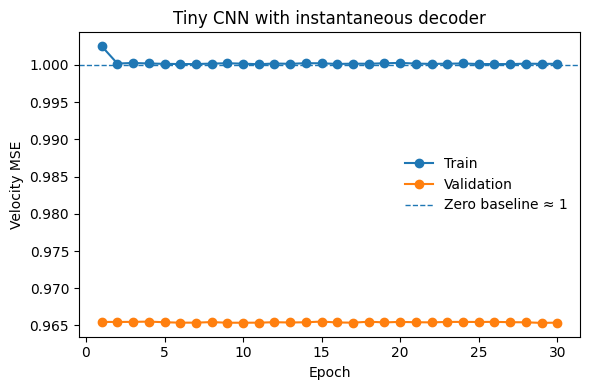

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation")
plt.axhline(1.0, linestyle="--", linewidth=1, label="Zero baseline ≈ 1")
plt.xlabel("Epoch")
plt.ylabel("Velocity MSE")
plt.title("Tiny CNN with instantaneous decoder")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def compute_val_r2_per_movie(
    model,
    val_loader,
    vel_mean,
    vel_std,
    gray_frames,
    device,
):
    model.eval()

    r2_per_seq = []
    pred_all = []
    target_all = []

    for batch in val_loader:
        movie = batch["movie"].to(device)
        target = batch["scene_vel"].to(device)  # raw px/s, (B, T, 2)

        pred_z = model(movie)                   # normalized, (B, T, 2)
        pred = pred_z * vel_std + vel_mean      # back to px/s

        pred = pred[:, gray_frames:, :]
        target = target[:, gray_frames:, :]

        # Per movie R² over both vx and vy together
        ss_res = ((target - pred) ** 2).sum(dim=(1, 2))
        target_mean = target.mean(dim=(1, 2), keepdim=True)
        ss_tot = ((target - target_mean) ** 2).sum(dim=(1, 2))

        r2 = 1.0 - ss_res / (ss_tot + 1e-8)

        r2_per_seq.extend(r2.detach().cpu().numpy())
        pred_all.append(pred.detach().cpu())
        target_all.append(target.detach().cpu())

    r2_per_seq = np.asarray(r2_per_seq)
    pred_all = torch.cat(pred_all, dim=0)        # (Nval, T-gray, 2)
    target_all = torch.cat(target_all, dim=0)

    return r2_per_seq, pred_all, target_all

r2_per_seq, pred_val, target_val = compute_val_r2_per_movie(
    model=tiny,
    val_loader=val_loader,
    vel_mean=vel_mean,
    vel_std=vel_std,
    gray_frames=gray_frames,
    device=device,
)

mean_r2 = np.mean(r2_per_seq)
sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

print("Mean R²:", mean_r2)
print("SEM R²:", sem_r2)
print("N validation movies:", len(r2_per_seq))
print("Min/Max R²:", r2_per_seq.min(), r2_per_seq.max())

NameError: name 'tiny' is not defined

/tmp/ipykernel_21747/2314121497.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


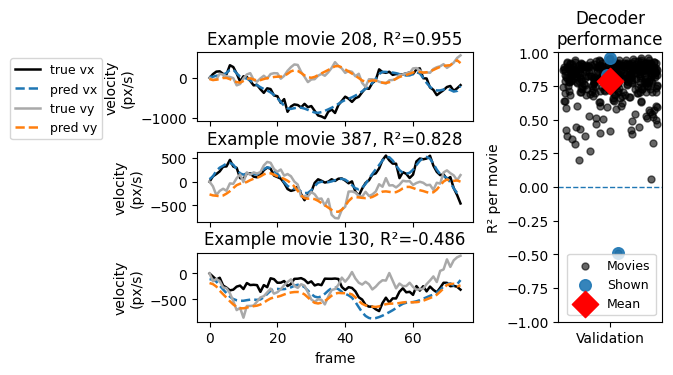

In [ ]:
from matplotlib.gridspec import GridSpec


def plot_validation_summary_two_columns(
    r2_per_seq,
    pred_val,
    target_val,
    n_examples=3,
    example_mode="best",  # "best", "worst", or "mixed"
    figsize=(11, 7),
):
    # Convert tensors to numpy if needed
    if hasattr(pred_val, "detach"):
        pred_val_np = pred_val.detach().cpu().numpy()
    else:
        pred_val_np = np.asarray(pred_val)

    if hasattr(target_val, "detach"):
        target_val_np = target_val.detach().cpu().numpy()
    else:
        target_val_np = np.asarray(target_val)

    r2_per_seq = np.asarray(r2_per_seq)

    # Choose example indices
    order = np.argsort(r2_per_seq)

    if example_mode == "best":
        example_idxs = order[-n_examples:][::-1]
    elif example_mode == "worst":
        example_idxs = order[:n_examples]
    elif example_mode == "mixed":
        example_idxs = np.array([
            order[-1],
            order[len(order) // 2],
            order[0],
        ])
        example_idxs = example_idxs[:n_examples]
    else:
        raise ValueError("example_mode must be 'best', 'worst', or 'mixed'.")

    mean_r2 = np.mean(r2_per_seq)
    sem_r2 = np.std(r2_per_seq, ddof=1) / np.sqrt(len(r2_per_seq))

    # Figure layout
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=len(example_idxs),
        ncols=2,
        width_ratios=[3.2, 1.2],
        wspace=0.45,
        hspace=0.45,
        figure=fig,
    )

    # -----------------------------
    # Left column: example traces
    # -----------------------------
    for row, idx in enumerate(example_idxs):
        ax = fig.add_subplot(gs[row, 0])

        pred = pred_val_np[idx]
        target = target_val_np[idx]

        t = np.arange(target.shape[0])

        ax.plot(t, target[:, 0], label="true vx", linewidth=1.8, c='k')
        ax.plot(t, pred[:, 0], label="pred vx", linewidth=1.8, linestyle="--")

        ax.plot(t, target[:, 1], label="true vy", linewidth=1.8, c='darkgray')
        ax.plot(t, pred[:, 1], label="pred vy", linewidth=1.8, linestyle="--")

        ax.set_title(f"Example movie {idx}, R²={r2_per_seq[idx]:.3f}")
        ax.set_ylabel("velocity\n(px/s)")

        if row == len(example_idxs) - 1:
            ax.set_xlabel("frame")
        else:
            ax.set_xticklabels([])

        if row == 0:
            ax.legend(ncol=1, fontsize=9, loc="upper left",
                      bbox_to_anchor=(-.7, 1.0),)

    # -----------------------------
    # Right column: R² scatter plot
    # -----------------------------
    ax_r2 = fig.add_subplot(gs[:, 1])

    x0 = 0
    rng = np.random.default_rng(0)
    x_jitter = x0 + rng.uniform(-0.15, 0.15, size=len(r2_per_seq))

    ax_r2.scatter(
        x_jitter,
        r2_per_seq,
        alpha=0.6,
        s=25,
        c="k",
        label="Movies",
    )

    # Highlight selected examples
    ax_r2.scatter(
        x_jitter[example_idxs],
        r2_per_seq[example_idxs],
        alpha=0.9,
        s=70,
        c="tab:blue",
        label="Shown",
    )

    # Mean marker + SEM
    ax_r2.scatter(
        x0,
        mean_r2,
        s=180,
        marker="D",
        c="red",
        label="Mean",
        zorder=5,
    )

    ax_r2.errorbar(
        x0,
        mean_r2,
        yerr=sem_r2,
        fmt="none",
        ecolor="red",
        capsize=5,
        linewidth=2,
        zorder=4,
    )

    ax_r2.axhline(0, linestyle="--", linewidth=1)
    ax_r2.set_xticks([x0])
    ax_r2.set_xticklabels(["Validation"])
    ax_r2.set_ylim(-1, 1)
    ax_r2.set_ylabel("R² per movie")
    ax_r2.set_title("Decoder\nperformance")
    ax_r2.legend(fontsize=9, loc="lower right")

    # fig.suptitle("Validation performance summary", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig

fig = plot_validation_summary_two_columns(
    r2_per_seq=r2_per_seq,
    pred_val=pred_val,
    target_val=target_val,
    n_examples=3,
    example_mode="mixed",
    figsize=(6, 3.5),
)